# Mushroom Edibility Classification — Milestone Report
**Team:** Haoyuan Deng, Dimitry Pianykh

**TA:** Mateo

# Part 0: Imports

In [ ]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils import shuffle, resample

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, PrecisionRecallDisplay,
    auc, roc_curve, RocCurveDisplay
)
from scipy.stats import spearmanr
import altair as alt
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import DecisionBoundaryDisplay

### Part 1: Mushroom Classification from Tabular Data

## 1.1: Loading and Processing Data

In [ ]:
%pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
secondary_mushroom = fetch_ucirepo(id=848)
X : pd.DataFrame = secondary_mushroom.data.features.copy()
y : pd.Series = secondary_mushroom.data.targets.copy().squeeze()
df : pd.DataFrame = X.copy()
df["class"] = y
print(secondary_mushroom.metadata)
print(secondary_mushroom.variables)

"""
The original dataset was from this link:
https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset
Sadly, on 4/9/2026 the website went down. We found a dataset on Kaggle
that seemed to be the same, so we use that below (code credit to StackOverflow).
Currently, we commented the below code out, but if the UCI-ML database goes down below,
the below import process works as well, but just comment out the above code.
"""
# import os
# import json
# import subprocess
# %pip install kaggle --upgrade -q
# os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
# kaggle_creds = {"username": "ilikepropane", "key": "KGAT_7c4fab56f6303dba9b0551a2c513936b"}
# with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
#     json.dump(kaggle_creds, f)
# os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
# !kaggle datasets download -d joebeachcapital/secondary-mushroom-dataset --unzip -p ./data
# for dirname, _, filenames in os.walk('./data'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
# df = pd.read_csv('./data/MushroomDataset/MushroomDataset/secondary_data.csv', sep = ';', on_bad_lines = 'skip')
# df.head()
# X = df.drop(columns=['class']).copy()
# y = df['class'].copy()

X, y = shuffle(X, y)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
print('Secondary shape:', X.shape)
print(X.head())
print(y.head())
missing = X.isnull().sum()
missing_pct = missing[missing > 0] / len(X) * 100
print("Missing value % per column:")
print(missing_pct.round(2))
print(f"\nTotal columns dropped: {(missing_pct > 5).sum()}")
print(f"Total columns interpolated: {((missing_pct > 0) & (missing_pct <= 5)).sum()}")

low_missing = X.isnull().mean() * 100
cols_to_drop = low_missing[low_missing > 5].index
cols_to_interpolate = low_missing[(low_missing > 0) & (low_missing <= 5)].index

X = X.drop(columns=cols_to_drop)

num_cols = X[cols_to_interpolate].select_dtypes(include="number").columns
cat_cols_missing = X[cols_to_interpolate].select_dtypes(include=["object", "category"]).columns

X[num_cols] = X[num_cols].interpolate(method="linear")
X[cat_cols_missing] = X[cat_cols_missing].apply(lambda col: col.fillna(col.mode()[0]))

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

assert X.isnull().sum().sum() == 0
y_encoded : np.ndarray = (y == 'e').astype(int).to_numpy()

X_encoded = pd.get_dummies(X, columns = cat_cols, drop_first = True)
scaler : StandardScaler = StandardScaler()
X_encoded = pd.DataFrame(
    scaler.fit_transform(X_encoded),
    columns=X_encoded.columns
)
print("X_encoded shape:", X_encoded.shape)

{'uci_id': 848, 'name': 'Secondary Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/848/data.csv', 'abstract': 'Dataset of simulated mushrooms for binary classification into edible and poisonous.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 61068, 'num_features': 20, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2021, 'last_updated': 'Wed Apr 10 2024', 'dataset_doi': '10.24432/C5FP5Q', 'creators': ['Dennis Wagner', 'D. Heider', 'Georges Hattab'], 'intro_paper': {'ID': 259, 'type': 'NATIVE', 'title': 'Mushroom data creation, curation, and simulation to support classification tasks', 'authors': 'Dennis Wagner, D. Heider, Georges Hattab', 'venue': 'Scientific Reports', 'year': 2021, 'journal': None, '

In [ ]:
# Mapping from letter codes to full names (from dataset documentation) so that charts later are readable.

color_map = {
    'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green',
    'p': 'pink', 'u': 'purple', 'e': 'red', 'w': 'white',
    'y': 'yellow', 'l': 'blue', 'o': 'orange', 'k': 'black', 'f': 'none'
}

shape_map = {
    'b': 'bell', 'c': 'conical', 'x': 'convex', 'f': 'flat',
    's': 'sunken', 'p': 'spherical', 'o': 'others'
}

surface_map = {
    'i': 'fibrous', 'g': 'grooves', 'y': 'scaly', 's': 'smooth',
    'h': 'shiny', 'l': 'leathery', 'k': 'silky', 't': 'sticky',
    'w': 'wrinkled', 'e': 'fleshy', 'f': 'none'
}

habitat_map = {
    'g': 'grasses', 'l': 'leaves', 'm': 'meadows', 'p': 'paths',
    'h': 'heaths', 'u': 'urban', 'w': 'waste', 'd': 'woods'
}

season_map = {
    's': 'spring', 'u': 'summer', 'a': 'autumn', 'w': 'winter'
}

ring_map = {
    'c': 'cobwebby', 'e': 'evanescent', 'r': 'flaring', 'g': 'grooved',
    'l': 'large', 'p': 'pendant', 's': 'sheathing', 'z': 'zone',
    'y': 'scaly', 'm': 'movable', 'f': 'none'
}

attachment_map = {
    'a': 'adnate', 'x': 'adnexed', 'd': 'decurrent', 'e': 'free',
    's': 'sinuate', 'p': 'pores', 'f': 'none'
}

spacing_map = {
    'c': 'close', 'd': 'distant', 'f': 'none'
}

bruise_map  = {'t': 'yes', 'f': 'no'}
ring_yn_map = {'t': 'yes', 'f': 'no'}

prefix_map = {
    'cap-color':           color_map,
    'cap-shape':           shape_map,
    'cap-surface':         surface_map,
    'gill-color':          color_map,
    'gill-attachment':     attachment_map,
    'gill-spacing':        spacing_map,
    'stem-color':          color_map,
    'stem-surface':        surface_map,
    'ring-type':           ring_map,
    'habitat':             habitat_map,
    'season':              season_map,
    'does-bruise-or-bleed': bruise_map,
    'has-ring':            ring_yn_map,
}

def rename_feature(col_name):
    parts = col_name.rsplit('_', 1)
    if len(parts) == 2:
        prefix, code = parts
        if prefix in prefix_map and code in prefix_map[prefix]:
            return f"{prefix}_{prefix_map[prefix][code]}"
    return col_name
X_encoded.columns = [rename_feature(c) for c in X_encoded.columns]

print("Sample renamed columns:")
print(list(X_encoded.columns[:15]))


Sample renamed columns:
['cap-diameter', 'stem-height', 'stem-width', 'cap-shape_conical', 'cap-shape_flat', 'cap-shape_others', 'cap-shape_spherical', 'cap-shape_sunken', 'cap-shape_convex', 'cap-color_red', 'cap-color_gray', 'cap-color_black', 'cap-color_blue', 'cap-color_brown', 'cap-color_orange']


## 1.2: Explorative Analysis of Data

In [ ]:
print('=== Missing Values===')
df_eda : pd.DataFrame = df.copy()
df_eda["class"] = df_eda["class"].map({"e" : "Edible", "p" : "Poisonous"})
# Dataframe for missing values and their percentages.
missing_df = pd.DataFrame({
    "column" : df.drop(columns=["class"]).isnull().mean().index,
    "missing_pct" : df.drop(columns=["class"]).isnull().mean().values * 100
}).query("missing_pct > 0").sort_values("missing_pct", ascending = False)
# Plot for the missing values.
missing_chart = alt.Chart(missing_df).mark_bar().encode(
    x = alt.X("missing_pct:Q", title = "Missing Percentages"),
    y = alt.Y("column:N", sort = "-x", title = "Feature")
).properties(title = "Missing Values per Feature")
missing_chart.display()

=== Missing Values===


alt.Chart(...)

In [ ]:
print("=== Class Distribution")
class_counts : pd.DataFrame = y.value_counts().reset_index()
class_counts.columns = ["class", "count_num"]
class_dist = alt.Chart(class_counts).mark_bar().encode(
    x = alt.X("class:N", axis = alt.Axis(
        labelExpr="datum.value === 'p' ? 'Poisonous' : 'Edible'",
        labelAngle = 0
    ), title = "Class"),
    y = alt.Y("count_num:Q", title = "Count"),
    color = alt.Color("class:N")
).properties(title = "Class Distribution", width = 300)
class_dist.display()

=== Class Distribution


alt.Chart(...)

In [ ]:
print('=== Continuous Feature Summary ===')
# Create the density dataframe.
num_df : pd.DataFrame = pd.DataFrame({
    "cap-diameter": df["cap-diameter"],
    "stem-height": df["stem-height"],
    "stem-width": df["stem-width"],
    "class": df["class"].map({"e": "Edible", "p": "Poisonous"})
}).melt(id_vars="class", var_name="feature", value_name="value")
num_df_sample : pd.DataFrame = num_df.groupby(["class", "feature"]).sample(800)
# Create the density plots.
density_plots = alt.Chart(num_df_sample).transform_density(
    "value", as_ = ["value", "density"],
    groupby = ["feature", "class"],
    extent = [-20, 60]
).mark_line().encode(
    x = alt.X("value:Q", title = "Value (cm, stem-width in mm)"),
    y = alt.Y("density:Q", title = "Density"),
    color = "class:N",
    facet = alt.Facet("feature:N", columns = 3)
).properties(title = "Density Plot of Continuous Features by Class")
density_plots.display()

=== Continuous Feature Summary ===


alt.Chart(...)

## 1.3: Common Model Functions

In [ ]:
def evaluate_model(name : str, y_test : np.ndarray, y_predicted : np.ndarray
                   , y_predicted_probabilities : np.ndarray = None) -> None:
  acc  = accuracy_score(y_test, y_predicted)
  prec = precision_score(y_test, y_predicted)
  rec  = recall_score(y_test, y_predicted)
  f1   = f1_score(y_test, y_predicted)
  auc  = (roc_auc_score(y_test, y_predicted_probabilities)
  if y_predicted_probabilities is not None else None)

  print(f'\n=== {name} ===')
  print(f'  Accuracy:  {acc:.4f}')
  print(f'  Precision: {prec:.4f}')
  print(f'  Recall:    {rec:.4f}')
  print(f'  F1 Score:  {f1:.4f}')
  if auc: print(f'  ROC-AUC:   {auc:.4f}')

  fig, ax = plt.subplots(figsize=(4, 3))
  ConfusionMatrixDisplay(
      confusion_matrix(y_test, y_predicted),
      display_labels = ["Poisonous", "Edible"]
  ).plot(ax = ax, colorbar = False, cmap = "Blues")
  ax.set_title(f'{name} — Confusion Matrix')
  plt.tight_layout()
  plt.show()

  return

In [ ]:
"""
Given a BaseEstimator, one-hot encoded predictor values, and response values,
  outputs the predicted values for the full-length array of the input n values.
"""
def output_prediction(estimator : BaseEstimator
                      , encoded_predictors : pd.DataFrame
                      , response : np.ndarray) -> np.ndarray:
  cv_indices = StratifiedKFold(n_splits = 5, shuffle = True)
  return cross_val_predict(estimator = estimator, X = encoded_predictors,
                           y = response,
                           cv = cv_indices,
                           method = "predict")

## 1.4: Lasso Logistic Regression with 5-Fold Cross-Validation
We use Logistic Regression as our baseline test, for both trying to figure out the decision boundary shape but also the underlying assumptions. That is, we know that logistic regression performs best for linear decision boundaries, and for non-normal distribution, if compared to LDA or NB it performs much better. However, as we can see below, the performance of the Logistic Regression classifier with Lasso regularization is pretty mediocre. We chose Lasso to get the most important feature subset, to compare with non-linear methods such as Random Forest later.


=== Logistic Regression ===
  Accuracy:  0.7402
  Precision: 0.7187
  Recall:    0.6838
  F1 Score:  0.7008


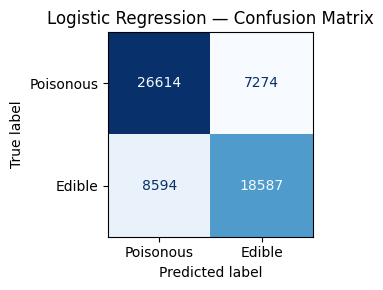

In [ ]:
"""
Logistic Regression with 5-fold CV.
"""
# Logistic regression with Lasso.
log_clf : BaseEstimator = LogisticRegression(penalty = "l1", solver = "liblinear", max_iter = 100)
evaluate_model("Logistic Regression", y_encoded, output_prediction(estimator = log_clf,
                                                   encoded_predictors = X_encoded,
                                                   response = y_encoded))

## 1.5: Depth-5 Decision Tree
Here we use another baseline model, more for the sake of interpretation. For five branches the results are worse than that of logistic regression, and we later draw out this tree, which highlights the most important decisions for its splits.


=== Decision Tree ===
  Accuracy:  0.7042
  Precision: 0.6240
  Recall:    0.8438
  F1 Score:  0.7174


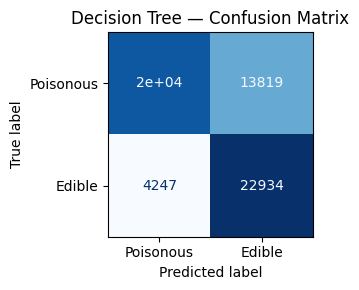

DecisionTreeClassifier(max_depth=5)

In [ ]:
X_unscaled = pd.get_dummies(X, columns = cat_cols, drop_first = True)
decision_tree_clf : DecisionTreeClassifier = DecisionTreeClassifier(max_depth = 5)
evaluate_model("Decision Tree", y_encoded, output_prediction(estimator = decision_tree_clf,
                                                   encoded_predictors = X_unscaled,
                                                   response = y_encoded))
decision_tree_clf.fit(X_unscaled, y_encoded)

## 1.6: Linear Discriminant Analysis with 5-Fold Cross Validation
The results for LDA are almost identical to that of Logistic Regression, which means that the features are most likely pretty normal, which is a key assumption of LDA.


=== LDA ===
  Accuracy:  0.7387
  Precision: 0.7171
  Recall:    0.6817
  F1 Score:  0.6990


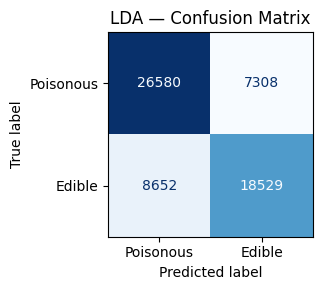

In [ ]:
"""
Linear Discriminant Analysis with 5-fold CV.
"""
lda_clf : BaseEstimator = LinearDiscriminantAnalysis()
evaluate_model("LDA", y_encoded, output_prediction(estimator = lda_clf,
                                                   encoded_predictors = X_encoded,
                                                   response = y_encoded))

## 1.7: Quadratic Discriminant Analysis with 5-Fold Cross Validation
Here we say that QDA performed better than Logistic Regression classification and LDA classification. Therefore, we know that the covariance matrices between the classes are not equal across all features, which suggests a non-linear boundary.


=== QDA ===
  Accuracy:  0.7938
  Precision: 0.7280
  Recall:    0.8568
  F1 Score:  0.7872


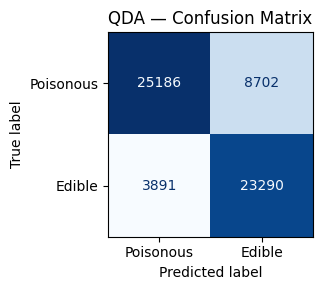

In [ ]:
qda_clf : BaseEstimator = QuadraticDiscriminantAnalysis(reg_param = 0.1)
evaluate_model("QDA", y_encoded, output_prediction(estimator = qda_clf,
                                                   encoded_predictors = X_encoded,
                                                   response = y_encoded))

## 1.8: Naive Bayes Classification with 5-Fold Cross Validation
The results from Naive Bayes classification evidently underperform those metrics of QDA, which suggests pretty clearly that the features within each class or correlated, that is, their covariance matrix is not diagonal.
Credit : https://medium.com/analytics-vidhya/naive-bayes-for-mixed-typed-data-in-scikit-learn-fb6843e241f0


=== Naive Bayes ===
  Accuracy:  0.6599
  Precision: 0.6627
  Recall:    0.4804
  F1 Score:  0.5570


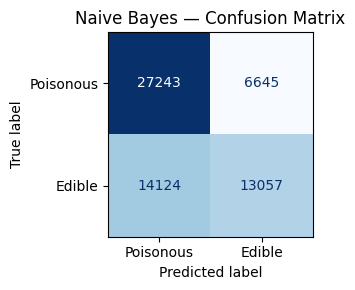

In [ ]:
numeric_cols : list[str] = X.select_dtypes(include="number").columns.tolist()
cat_cols : list[str] = X.select_dtypes(include=["object", "category"]).columns.tolist()

cv_indices : np.ndarray = StratifiedKFold(n_splits=5, shuffle=True)
y_predicted : np.ndarray = np.zeros_like(y_encoded)

for train_indices, test_indices in cv_indices.split(X, y_encoded):
    X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
    y_train : pd.DataFrame = y_encoded[train_indices]

    encoder : OrdinalEncoder = OrdinalEncoder()
    X_train_ord = encoder.fit_transform(X_train[cat_cols])
    X_test_ord = encoder.transform(X_test[cat_cols])

    gaussian_nb_clf : BaseEstimator = GaussianNB()
    categorical_nb_clf : BaseEstimator = CategoricalNB()
    gaussian_nb_clf.fit(X_train[numeric_cols], y_train)
    categorical_nb_clf.fit(X_train_ord, y_train)

    log_proba_num : np.ndarray = gaussian_nb_clf.predict_log_proba(X_test[numeric_cols])
    log_proba_cat : np.ndarray = categorical_nb_clf.predict_log_proba(X_test_ord)
    log_prior : np.ndarray = np.log(gaussian_nb_clf.class_prior_)
    log_proba_combined : np.ndarray = log_proba_num + log_proba_cat - log_prior
    y_predicted[test_indices] = np.argmax(log_proba_combined, axis=1)

evaluate_model(name = "Naive Bayes", y_test = y_encoded, y_predicted = y_predicted)

## 1.5 Decision Boundary Shape
In the following sections, we prod for the decision boundary shape using Support Vector Machines with differnet kernels. We try a linear kernel, a degree-3 polynomial kernel, and a radial kernel.


### 1.5.1: Linear Kernel SVM
We can see that the linear kernel SVM performs roughly as well as the Logistic Regression classifier and LDA, which is expected due to their linear decision bounds.


=== Linear Kernel SVM ===
  Accuracy:  0.7393
  Precision: 0.7163
  Recall:    0.6861
  F1 Score:  0.7009


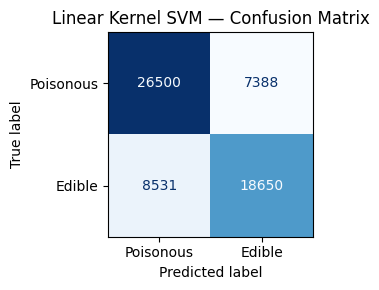

In [ ]:
linear_svm_clf : BaseEstimator = LinearSVC()
evaluate_model("Linear Kernel SVM", y_encoded, output_prediction(estimator = linear_svm_clf,
                                                   encoded_predictors = X_encoded,
                                                   response = y_encoded))

### 1.5.2: Degree-3 Polynomial Kernel SVM
The degree-3 polynomial kernel SVM performs radically better than any of the methods we have seen so far, which suggests that the decision boundary is not linear.



=== Degree 3 Polynomial Kernel SVM ===
  Accuracy:  0.9623
  Precision: 0.9607
  Recall:    0.9543
  F1 Score:  0.9575


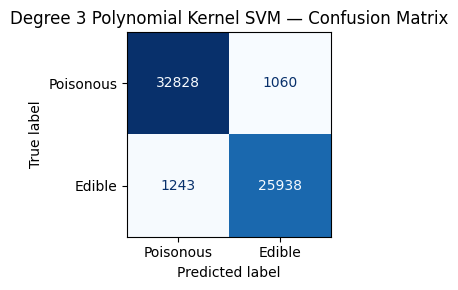

In [ ]:
"""
Degree 3 Polynomial Kernel SVM
"""
poly_svm_clf : BaseEstimator = SVC(kernel = "poly")
evaluate_model("Degree 3 Polynomial Kernel SVM", y_encoded, output_prediction(estimator = poly_svm_clf,
                                                   encoded_predictors = X_encoded,
                                                   response = y_encoded))

### 1.5.3: Radial Kernel SVM
The SVM results for a radial kernel are slightly better than that of the degree-3 polynomial kernel, which suggests some locality property to the decision boundaries for the classes.


=== Radial Kernel SVM ===
  Accuracy:  0.9704
  Precision: 0.9724
  Recall:    0.9607
  F1 Score:  0.9665


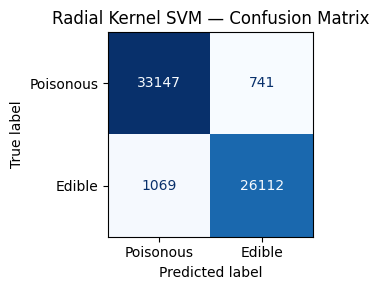

In [ ]:
"""
Radial Kernel SVM
"""
radial_svm_clf : BaseEstimator = SVC(kernel = "rbf")
evaluate_model("Radial Kernel SVM", y_encoded, output_prediction(estimator = radial_svm_clf,
                                                   encoded_predictors = X_encoded,
                                                   response = y_encoded))

## 1.6: Complex Classification
Here we present more complex methods for classification, in order to see how highg of the classification metrics we can get.


### 1.6.1: Random Forest Classification
The results for Random Forest Classification is high, which is expected.



=== Random Forests ===
  Accuracy:  0.9969
  Precision: 0.9968
  Recall:    0.9962
  F1 Score:  0.9965


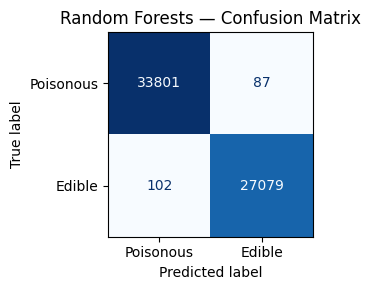

In [ ]:
rf_clf : BaseEstimator = RandomForestClassifier(n_estimators=100)
evaluate_model("Random Forests", y_encoded, output_prediction(estimator = rf_clf,
                                                   encoded_predictors = X_encoded,
                                                   response = y_encoded))

## 1.7: Below we provide visualizations.

### 1.7.1: Decision Tree Visualization
We draw the plot for 3/5 layers of the decision tree classifier that we previously fit.

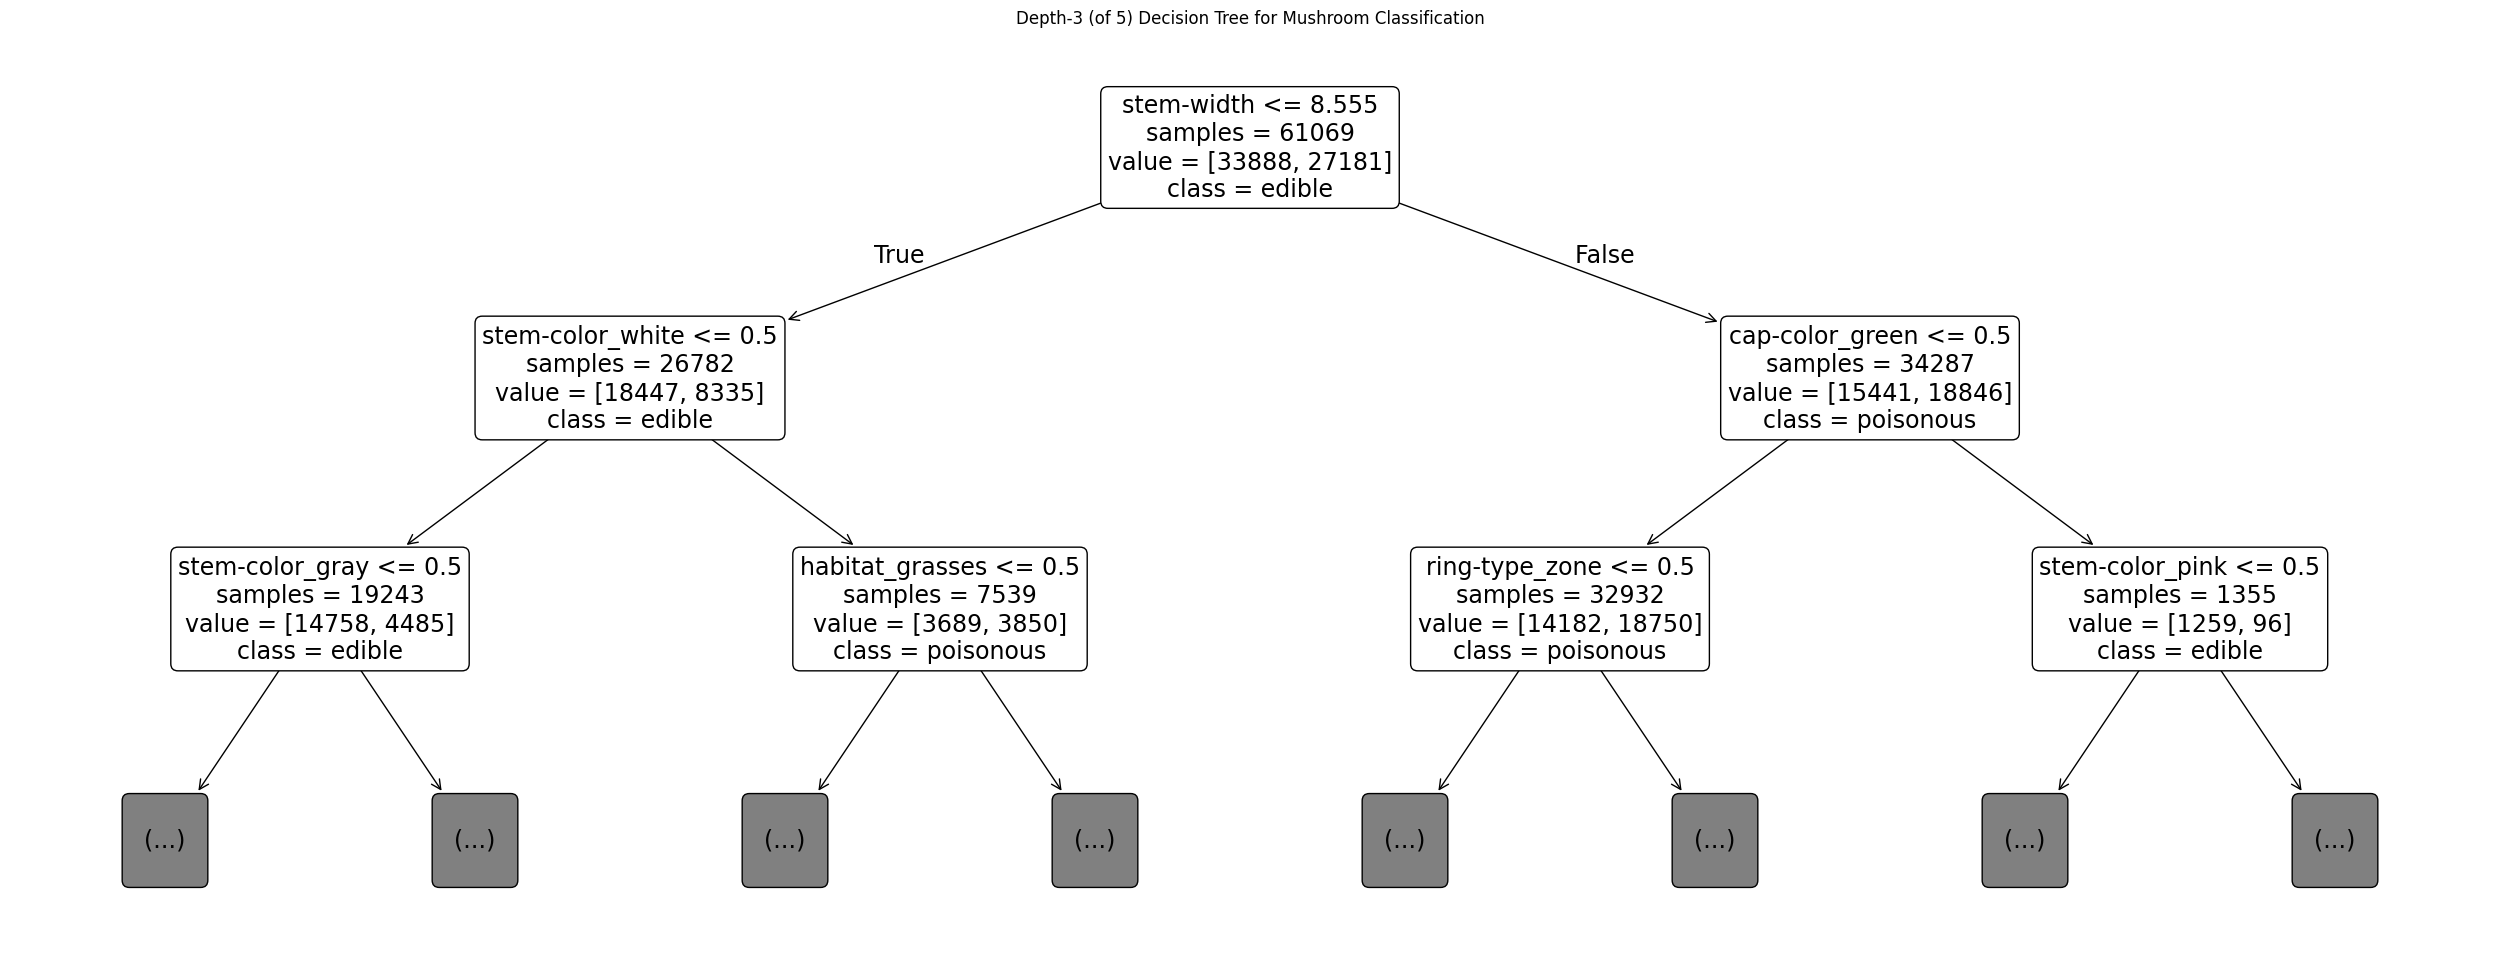

In [ ]:
plt.figure(figsize=(32, 12))
plot_tree(
    decision_tree_clf,
    max_depth = 2,
    feature_names = X_encoded.columns.to_list(),
    class_names = ["edible", "poisonous"],
    impurity = False,
    rounded = True
)
plt.title("Depth-3 (of 5) Decision Tree for Mushroom Classification")
plt.show()

### 1.7.2: Top Features
Here we provide the top features ranked by the Logistic Regression and Random Forest classifiers. We can see that some features show up approximately in the same locations, such as certain stem colors. However, stem-width is not nearly as an important feature for Logistic Regression classification as it is for Random Forests. The correlation is low, and the p-value is nowhere near enough to suggest that their rankings are the same. This is expected, as Logistic Regression determines features which help it lipredict on a linear scale, and we determined that the boundary is not linear.

In [ ]:
"""
Comparing the top features from random forest and logistic classification with Lasso.
"""
# Construct a normal fit on all fo the data.
log_clf.fit(X_encoded, y_encoded)
rf_clf.fit(X_encoded, y_encoded)
# Get the feature importances.
log_feature_importances : np.ndarray = np.abs(log_clf.coef_[0])
rf_feature_importances : np.ndarray = rf_clf.feature_importances_
# Calculate the spearman metrics.
corr, p_value = spearmanr(log_feature_importances, rf_feature_importances)
print(f"Spearman r={corr:.3f}, p={p_value:.4f}")
feature_names = X_encoded.columns
log_df = pd.DataFrame({"Feature": feature_names, "Importance": log_feature_importances})
rf_df = pd.DataFrame({"Feature": feature_names, "Importance": rf_feature_importances})
top_n : int = 10 # top important feature count.
log_top : pd.DataFrame = log_df.nlargest(top_n, "Importance")
rf_top : pd.DataFrame = rf_df.nlargest(top_n, "Importance")
# Plot the charts.
log_chart = alt.Chart(log_top).mark_bar().encode(
    x = alt.X("Importance:Q"),
    y = alt.Y("Feature:N", sort = "-x"),
).properties(title = f"Lasso Logistic Regression With Top {top_n} Features")
rf_chart = alt.Chart(rf_top).mark_bar().encode(
    x = alt.X("Importance:Q"),
    y = alt.Y("Feature:N", sort = "-x"),
).properties(title = f"Random Forest Classification With Top {top_n} Features")
log_chart | rf_chart

Spearman r=-0.030, p=0.8179


alt.HConcatChart(...)

### 1.7.3: SVM Decision Boundary Plots
Here we plot the SVM decision boundaries. We use mutual information between a feature and its class, and choose the highest ones, because that would lead to a less clustered graph. Furthermore, we randomly select 200 samples in order to make the graph easier to read.
Credit MI: https://medium.com/@miramnair/feature-selection-mutual-information-a0def943e1ed
Credit Plots: https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html

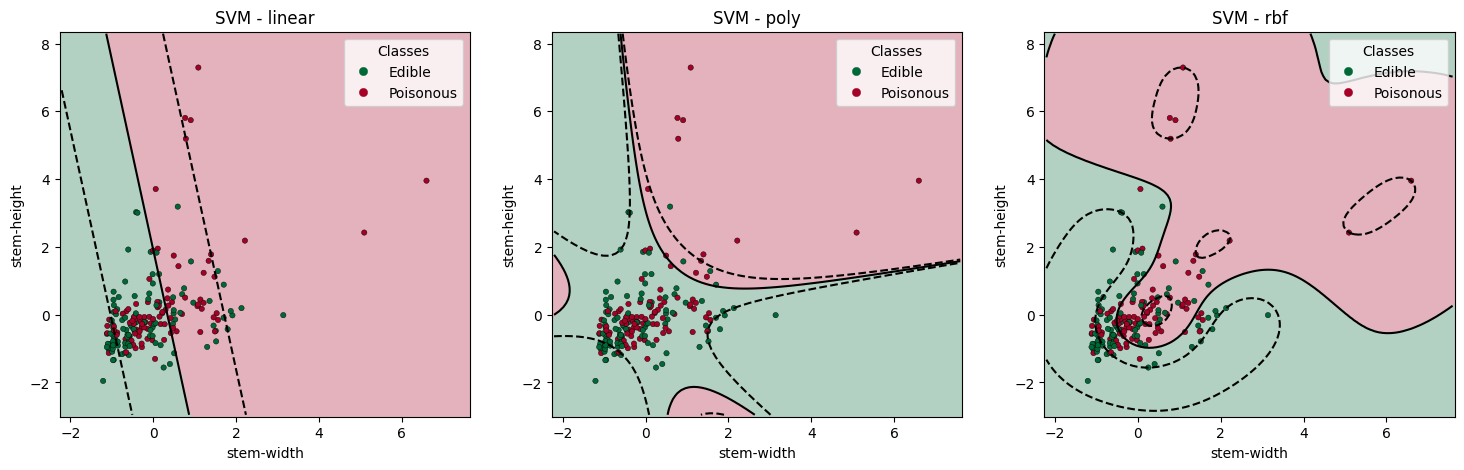

In [ ]:
# Set up.
kernels : list[tuple] = [("linear", {}), ("poly", {"degree" : 3}), ("rbf", {})]
top_2mi_features : list[str] = pd.DataFrame({
    "Feature" : X_encoded.columns,
    "MI": mutual_info_classif(X_encoded, y_encoded)
}).nlargest(2, "MI")["Feature"].tolist()
X_top2 : np.ndarray = X_encoded[top_2mi_features].values
X_top2_sample, y_sample = resample(X_top2, y_encoded, n_samples=200)
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
# Plotting using DecisionBoundaryDisplay.
for axis, (kernel, params) in zip(axes, kernels):
  svm_clf : BaseEstimator = SVC(kernel = kernel, **params)
  svm_clf.fit(X_top2_sample, y_sample)
  DecisionBoundaryDisplay.from_estimator(
      svm_clf, X_top2_sample, ax = axis,
      response_method = "predict",
      plot_method = "pcolormesh",
      cmap = "RdYlGn_r",
      alpha = 0.3
  )
  DecisionBoundaryDisplay.from_estimator(
      svm_clf, X_top2_sample, ax = axis,
      response_method = "decision_function",
      plot_method = "contour",
      levels = [-1, 0, 1],
      colors = ["k", "k", "k"],
      linestyles = ["--", "-", "--"],
  )
  scatter = axis.scatter(X_top2_sample[:, 0],
                         X_top2_sample[:, 1],
                         c = y_sample,
                         s = 15,
                         cmap = "RdYlGn_r",
                         vmin = 0,
                         vmax = 1,
                         edgecolors = "k",
                         linewidths = 0.3)
  handles, _ = scatter.legend_elements()
  axis.legend(handles, ["Edible", "Poisonous"], loc="upper right", title="Classes")
  axis.set_xlabel(top_2mi_features[0])
  axis.set_ylabel(top_2mi_features[1])
  axis.set_title(f"SVM - {kernel}")
plt.show()

### 1.7.4: Precision-Recall and ROC curve for Random Forest Classification

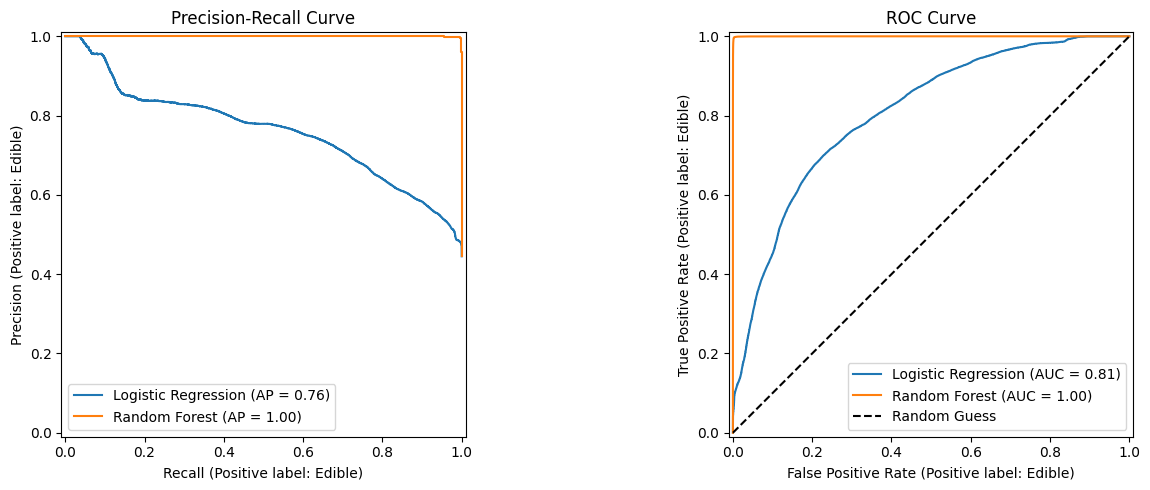

In [ ]:
y_named = y.map({'e': 'Edible', 'p': 'Poisonous'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))
cv_indices = StratifiedKFold(n_splits = 5, shuffle = True)
# Get probabilities for both models.
log_probs = cross_val_predict(
    LogisticRegression(penalty = "l1", solver = "liblinear", max_iter = 1000),
    X_encoded, y_encoded, cv = cv_indices, method = "predict_proba"
)[:, 1]
rf_probs = cross_val_predict(
    RandomForestClassifier(n_estimators = 100),
    X_encoded, y_encoded, cv = cv_indices, method = "predict_proba"
)[:, 1]
# Display precision-recall.
PrecisionRecallDisplay.from_predictions(
    y_named, log_probs, name = "Logistic Regression", ax = ax1, pos_label = "Edible")
PrecisionRecallDisplay.from_predictions(
    y_named, rf_probs, name = "Random Forest", ax = ax1, pos_label = "Edible")
ax1.set_title("Precision-Recall Curve")
# Display ROC curve.
RocCurveDisplay.from_predictions(
    y_named, log_probs, name = "Logistic Regression", ax = ax2, pos_label = "Edible")
RocCurveDisplay.from_predictions(
    y_named, rf_probs, name = "Random Forest", ax = ax2, pos_label = "Edible")
ax2.plot([0, 1], [0, 1], "k--", label = "Random Guess")
ax2.set_title("ROC Curve")
ax2.legend()
plt.tight_layout()
plt.show()